In [ ]:
! pip install scikit-learn

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (OrdinalEncoder, OneHotEncoder,StandardScaler, MinMaxScaler,RobustScaler, PowerTransformer)
from sklearn.model_selection import train_test_split
# from scipy.ndimage import gaussian_filter1d
# from scipy.stats import zscore
# import warnings
# warnings.filterwarnings('ignore')


# **EDA**

In [3]:
df = pd.read_csv(r"D:\Uni_Projects\Ass Machine\Data\car_price.csv")

In [4]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832.0,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,NaN,NaN,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601.0,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682.0,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,NaN,Like New,73577.10,Mustang


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2325 non-null   float64
 4   Fuel Type     2375 non-null   object 
 5   Transmission  2350 non-null   object 
 6   Mileage       2300 non-null   float64
 7   Condition     2400 non-null   object 
 8   Price         2375 non-null   float64
 9   Model         2425 non-null   object 
dtypes: float64(3), int64(2), object(5)
memory usage: 195.4+ KB


In [7]:
df.shape

(2500, 10)

In [8]:
df.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2325.000000,2300.000000,2375.000000
mean,1250.50000,2011.6268,3.479097,148713.113913,52500.564118
std,721.83216,6.9917,1.433089,88219.214833,27186.590166
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,69809.750000,28980.710000
50%,1250.50000,2012.0000,3.400000,148891.500000,53199.720000
75%,1875.25000,2018.0000,4.700000,225243.250000,75556.900000
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


In [11]:
df.describe(include="O")

,Brand,Fuel Type,Transmission,Condition,Model
count,2500,2375,2350,2400,2425
unique,7,4,2,3,28
top,Toyota,Diesel,Manual,Used,Corolla
freq,374,624,1229,823,101


In [12]:
df.isnull().sum()

Car ID            0
Brand             0
Year              0
Engine Size     175
Fuel Type       125
Transmission    150
Mileage         200
Condition       100
Price           125
Model            75
dtype: int64

<Axes: >

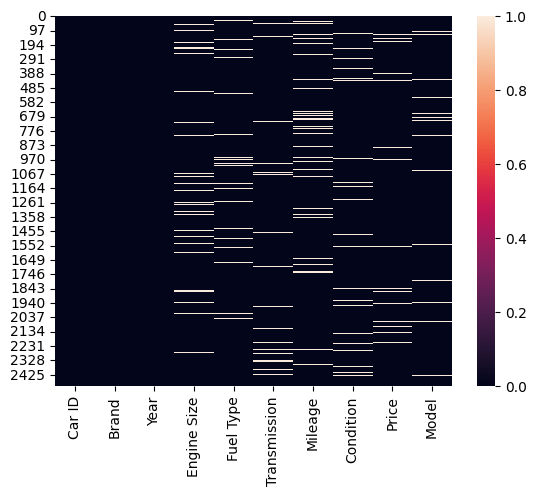

In [15]:
sns.heatmap(df.isnull())

The dataset exhibits a significant amount of missing data across multiple features. Pre-processing and imputation are required to handle these nulls before proceeding with further analysis or training

In [13]:
df.duplicated().sum()

np.int64(0)

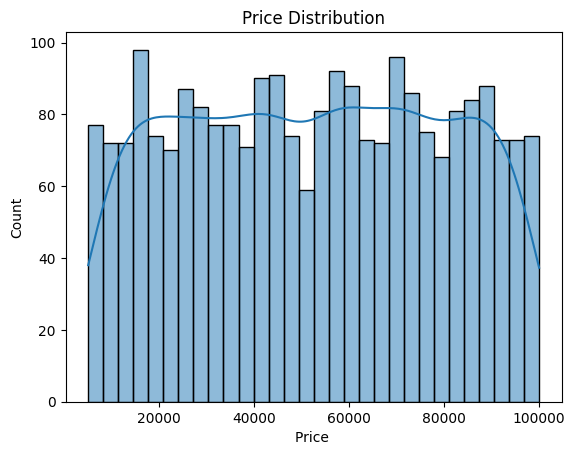

In [21]:
sns.histplot(df['Price'], bins=30, kde=True)
plt.xlabel("Price ")
plt.title("Price Distribution")
plt.show()

The distribution of car prices appears approximately uniform, with no strong central peak or skewness. This suggests that prices are evenly distributed across the dataset range, rather than concentrated around a specific value.

<Axes: xlabel='Engine Size'>

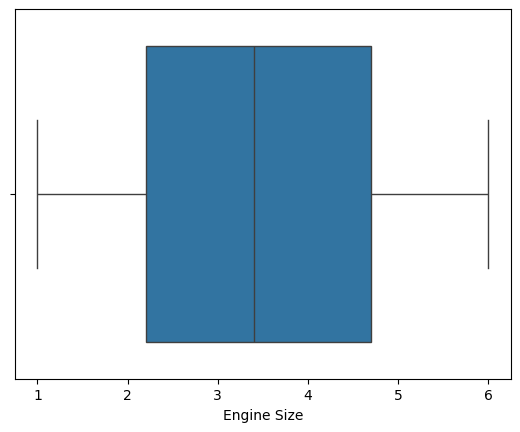

In [ ]:
sns.boxplot(data=df, x= 'Engine Size')

<Axes: xlabel='Mileage'>

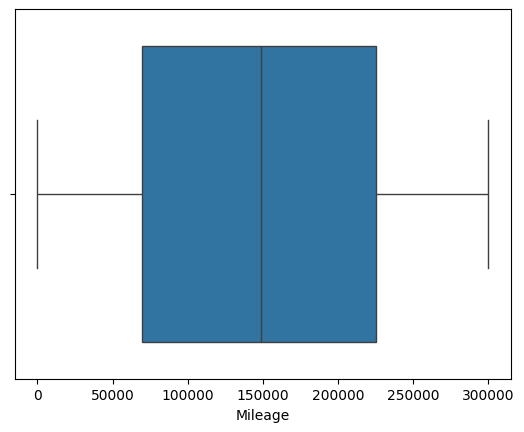

In [55]:
sns.boxplot(data=df, x= 'Mileage')

<Axes: xlabel='Brand', ylabel='Price'>

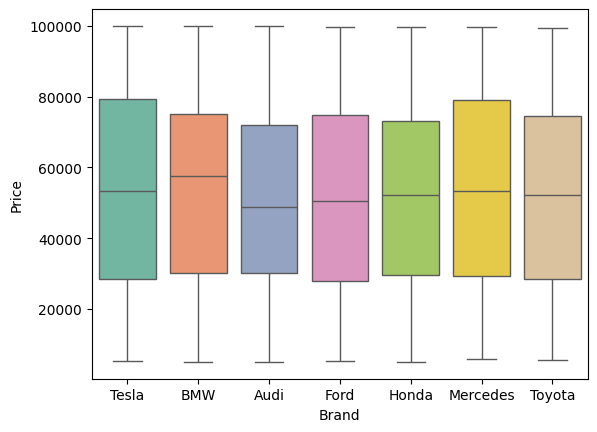

In [31]:
sns.boxplot(x='Brand', y='Price', data=df, hue="Brand", palette="Set2")

"The boxplot indicates a uniform price distribution across all car brands. The median prices are relatively consistent, and the interquartile range (IQR) shows similar variability for each brand, suggesting that brand name is not a significant differentiator for price in this dataset.

Text(0.5, 1.0, 'Fuel Type count')

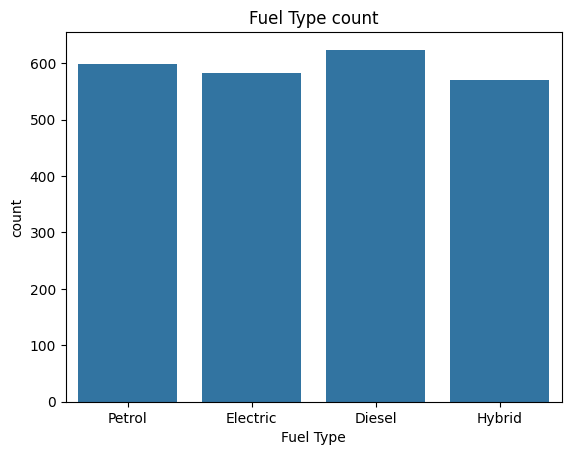

In [37]:
sns.countplot(data=df, x='Fuel Type')
plt.title("Fuel Type count")

"The bar chart reveals a well-balanced distribution of fuel types. Diesel shows the highest frequency, while Hybrid is the least, though the difference is minimal. This balance is crucial for ensuring unbiased model performance across all categories

Text(0.5, 1.0, 'Transmission count')

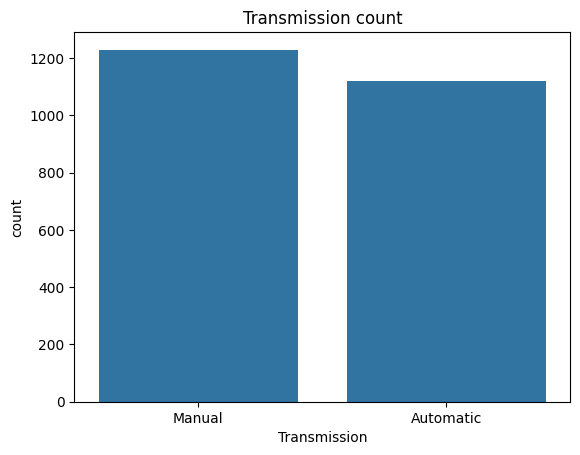

In [39]:
sns.countplot(data= df, x = 'Transmission')
plt.title("Transmission count")


This chart shows the distribution of transmission types. Both Manual and Automatic cars are well-represented in the dataset, with a slightly higher number of manual cars. The data is balanced, which is good for analysis

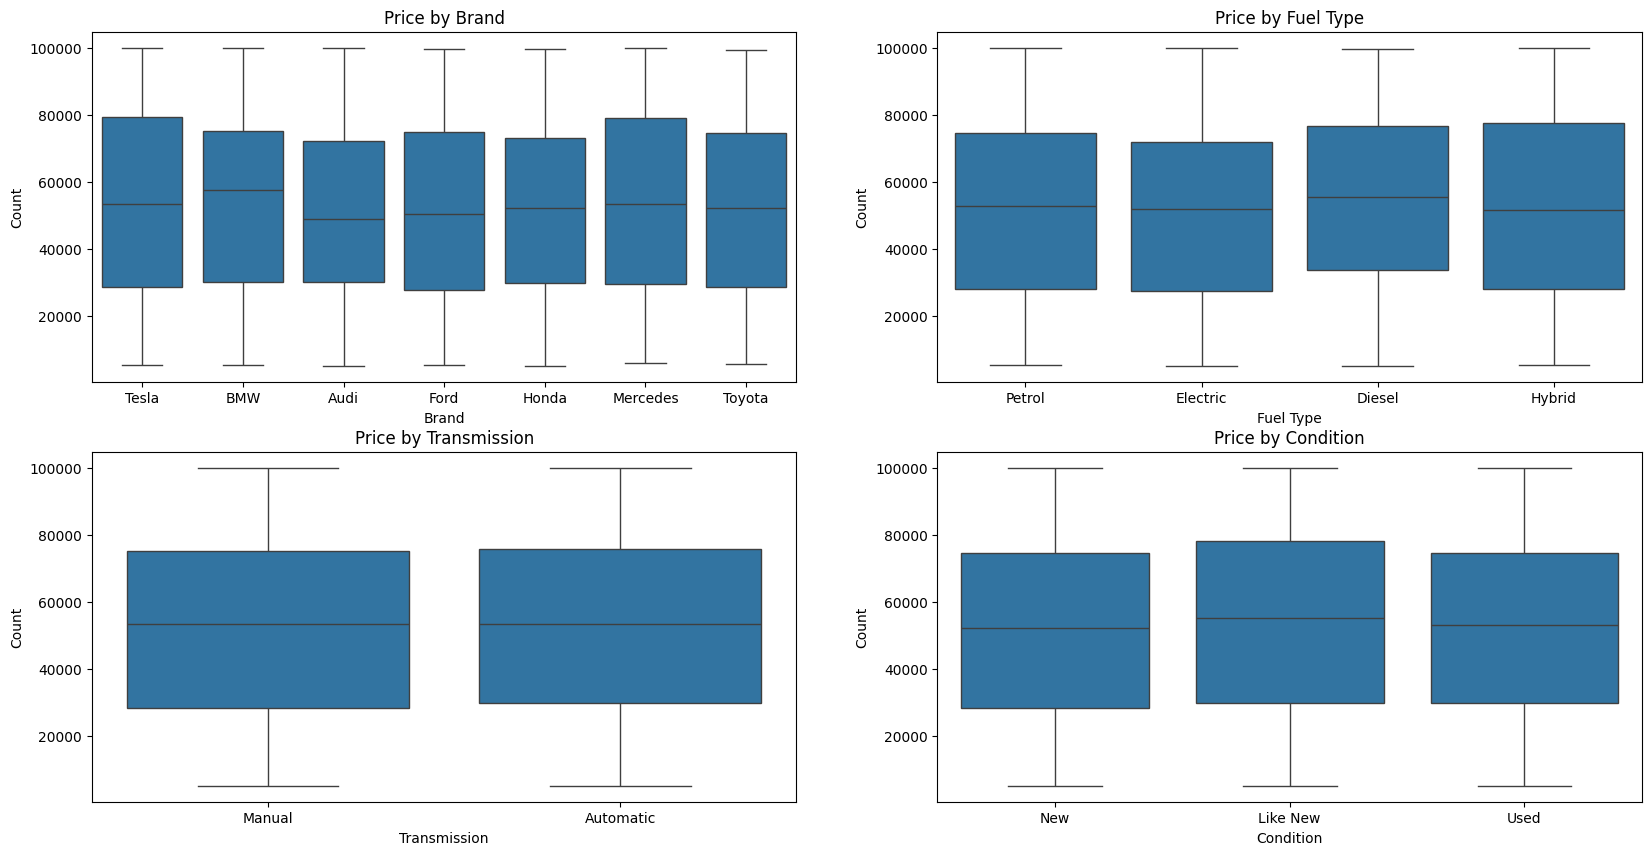

In [46]:
figs,axes =plt.subplots(2,2,figsize=(20,10))
features =['Brand', 'Fuel Type', 'Transmission', 'Condition']
for ax, col in zip(axes.flatten(), features):
    sns.boxplot(data = df, x=col, y='Price',ax=ax)
    ax.set_title(f"Price by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
plt.show()

"The categorical analysis reveals that car prices are consistently distributed across all features. Brand, Fuel Type, Transmission, and Condition show nearly identical price ranges and medians (around 50,000), with no significant outliers. This suggests that in this specific dataset, these categorical variables do not have a strong individual impact on the car's final price

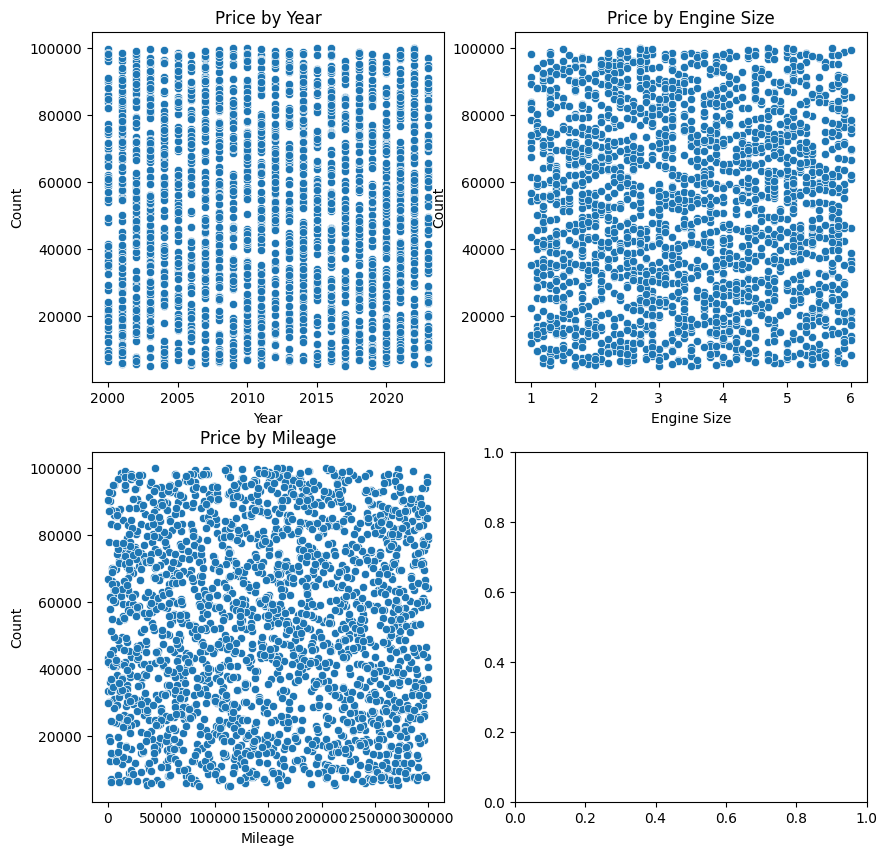

In [52]:
figs,axes =plt.subplots(2,2,figsize=(10,10))
features =['Year', 'Engine Size', 'Mileage']
for ax, col in zip(axes.flatten(), features):
    sns.scatterplot(data = df, x=col, y='Price',ax=ax)
    ax.set_title(f"Price by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
plt.show()

The scatter plots reveal no clear linear relationship between Price and numerical features like Year, Engine Size, or Mileage. The data points are highly dispersed, suggesting a very low correlation.

<Axes: >

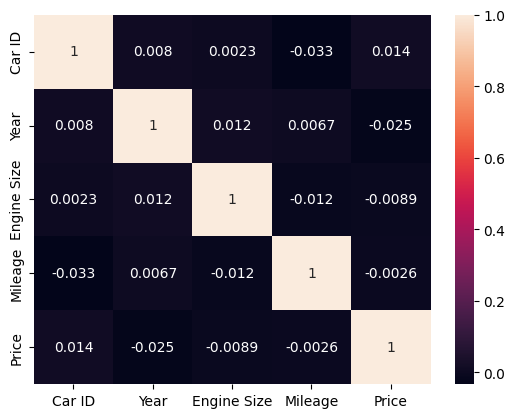

In [53]:
sns.heatmap(df.corr(numeric_only=True), annot= True)

There is a near-zero correlation between all features, including Price, Mileage, and Year. In a real-world scenario, we would expect a strong negative correlation between mileage and price, and a positive correlation between year and price. The current values (ranging from -0.03 to 0.01) indicate that the variables are statistically independent."

# **Data Preprocessing**

### Train/test split

In [63]:
df.drop('Car ID', axis=1, inplace=True)

In [65]:
x = df.drop(columns='Price')
y = df['Price']
x 

,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Model
0,Tesla,2016,2.3,Petrol,Manual,114832.0,New,Model X
1,BMW,2018,4.4,Electric,Manual,NaN,NaN,5 Series
2,Audi,2013,4.5,Electric,Manual,181601.0,New,A4
3,Tesla,2011,4.1,Diesel,Automatic,68682.0,New,Model Y
4,Ford,2009,2.6,Diesel,Manual,NaN,Like New,Mustang
...,...,...,...,...,...,...,...,...
2495,Audi,2020,2.4,Petrol,Automatic,22650.0,Like New,Q5
2496,Audi,2001,5.7,Hybrid,NaN,NaN,Like New,A3
2497,Ford,2021,NaN,Hybrid,Manual,272827.0,Like New,Fiesta
2498,Audi,2002,4.5,Diesel,Manual,229164.0,Like New,Q5


In [66]:
x_train , x_test , y_train , y_test = train_test_split( x, y , test_size=0.2 ,random_state= 1)


In [67]:
print(f"Train: {x_train.shape} | Test: {x_test.shape}")

Train: (2000, 8) | Test: (500, 8)


### Handling Missing Values

In [69]:
df.isnull().sum()

Brand             0
Year              0
Engine Size     175
Fuel Type       125
Transmission    150
Mileage         200
Condition       100
Price           125
Model            75
dtype: int64

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         2500 non-null   object 
 1   Year          2500 non-null   int64  
 2   Engine Size   2325 non-null   float64
 3   Fuel Type     2375 non-null   object 
 4   Transmission  2350 non-null   object 
 5   Mileage       2300 non-null   float64
 6   Condition     2400 non-null   object 
 7   Price         2375 non-null   float64
 8   Model         2425 non-null   object 
dtypes: float64(3), int64(1), object(5)
memory usage: 175.9+ KB


In [70]:
df.head()

,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,Tesla,2016,2.3,Petrol,Manual,114832.0,New,26613.92,Model X
1,BMW,2018,4.4,Electric,Manual,NaN,NaN,14679.61,5 Series
2,Audi,2013,4.5,Electric,Manual,181601.0,New,44402.61,A4
3,Tesla,2011,4.1,Diesel,Automatic,68682.0,New,86374.33,Model Y
4,Ford,2009,2.6,Diesel,Manual,NaN,Like New,73577.10,Mustang


In [73]:
category_col = x_train.select_dtypes(include='O').columns.tolist()
categorical_imputer = SimpleImputer(strategy="most_frequent")
x_train[category_col] = categorical_imputer.fit_transform(x_train[category_col])


In [74]:
x_test[category_col] = categorical_imputer.transform(x_test[category_col])

In [78]:
numeric_col = x_train.select_dtypes(include=np.number).columns.tolist()
numeric_imputer = SimpleImputer(strategy='mean')
x_train[numeric_col] = numeric_imputer.fit_transform(x_train[numeric_col])

In [79]:
x_test[numeric_col] = numeric_imputer.transform(x_test[numeric_col])

In [80]:
x_train.head()

,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Model
918,Mercedes,2006.0,1.5,Petrol,Automatic,18013.0,Used,C-Class
1699,Ford,2004.0,1.5,Electric,Automatic,293238.0,New,Mustang
639,Ford,2010.0,2.4,Diesel,Manual,220412.0,Used,Focus
1002,Ford,2016.0,2.6,Diesel,Automatic,1669.0,New,Fiesta
1352,BMW,2022.0,1.5,Hybrid,Automatic,162187.0,Like New,X5


In [ ]:
x_train.isnull().sum()

Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Model           0
dtype: int64

In [82]:
x_test.isnull().sum()

Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Model           0
dtype: int64